<a href="https://colab.research.google.com/github/CiaraFarrellSETU/phd/blob/main/Turlough_DRY.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import find_peaks
from scipy.stats import linregress
import pymannkendall as mk
import datetime

In [2]:

# Ensure pymannkendall is installed and imported
try:
    import pymannkendall as mk
except ModuleNotFoundError:
    print("pymannkendall not found. Installing...")
    !pip install pymannkendall
    import pymannkendall as mk # Re-import after installation

In [3]:

# Replace with the actual path to CSV file
file_path = '/content/Glenamaddy-2021-01-01-2026-05-28.csv'

try:
    # Read the CSV file into a pandas DataFrame
    df = pd.read_csv(file_path)
    print("CSV file read successfully!")
    # Display the first few rows of the DataFrame
    print(df.head())
    #errors incase issues with file
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please check the path.")
except pd.errors.EmptyDataError:
    print(f"Error: The file '{file_path}' is empty.")
except Exception as e:
    print(f"An error occurred while reading the CSV file: {e}")

CSV file read successfully!
             Date/Time  Stage (mAOD)  log_elev (mAOD)        name   code
0  2021-01-01 01:00:00         79.23             75.3  Glenamaddy  GSI26
1  2021-01-01 02:00:00         79.23             75.3  Glenamaddy  GSI26
2  2021-01-01 03:00:00         79.23             75.3  Glenamaddy  GSI26
3  2021-01-01 04:00:00         79.23             75.3  Glenamaddy  GSI26
4  2021-01-01 05:00:00         79.23             75.3  Glenamaddy  GSI26


In [4]:
# Data Loading & Initial Inspection
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47365 entries, 0 to 47364
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Date/Time        47365 non-null  object 
 1   Stage (mAOD)     45715 non-null  float64
 2   log_elev (mAOD)  45715 non-null  float64
 3   name             47365 non-null  object 
 4   code             47365 non-null  object 
dtypes: float64(2), object(3)
memory usage: 1.8+ MB
None


In [5]:
#column names
print(df.columns)

Index(['Date/Time', 'Stage (mAOD)', 'log_elev (mAOD)', 'name', 'code'], dtype='object')


In [6]:
#checking for NAN vlaues
print(df.isnull().sum())

Date/Time             0
Stage (mAOD)       1650
log_elev (mAOD)    1650
name                  0
code                  0
dtype: int64


In [7]:
#Ensure Date/Time is converted to datetime objects
df['Date/Time'] = pd.to_datetime(df['Date/Time'], errors='coerce')

# Drop any rows where the date couldn't be parsed (safety check)
df = df.dropna(subset=['Date/Time'])

# Set'Date/Time' column as the DataFrame's index
df.set_index('Date/Time', inplace=True)

# Sort the index (Required for time-interpolation) in chronological order
df = df.sort_index()

# Now perform the interpolation unction estimates and fills in NaN (missing) values based on the time difference between the valid data points
df['Stage (mAOD)'] = df['Stage (mAOD)'].interpolate(method='time')

#prints a confirmation message and shows the data type of the DataFrame's index, verifying that it is now a datetime index.
print("Interpolation successful. New Index Type:", type(df.index))

Interpolation successful. New Index Type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>


In [8]:
# Sampling Rate Check: calculates the difference between consecutive timestamps
time_diffs = df.index.to_series().diff().dropna()
print(f"\nMedian Sampling Interval: {time_diffs.median()}")

#if gives Median Sampling Interval: 0 days 01:00:00 : dataset is hourly


Median Sampling Interval: 0 days 01:00:00


In [9]:

#basic statistical summary on the 'Stage (mAOD)' column of  DataFrame
stats = df['Stage (mAOD)'].describe()
print("\n--- Summary Statistics ---")
print(stats)


--- Summary Statistics ---
count    47365.000000
mean        77.196385
std          1.404347
min         75.280000
25%         75.710000
50%         77.050000
75%         78.480000
max         79.830000
Name: Stage (mAOD), dtype: float64


In [17]:
print("\nAnalyzing 5-year historical drainage dynamics...")
target_col = 'Stage (mAOD)'

# Calculate hourly change (delta h)
df['dh'] = df[target_col].diff()

# Isolate true natural drainage events (< -2mm/hr)
draining_phases = df[df['dh'] < -0.002].copy()

# Group by water height rounded cleanly to 2 decimal places
draining_phases['stage_bin'] = draining_phases[target_col].round(2)
recession_profile = draining_phases.groupby('stage_bin')['dh'].median()

# Reindex and interpolate the lookup table cleanly to prevent floating point gaps
historical_min = round(df[target_col].min(), 2)
historical_max = round(df[target_col].max(), 2)

# Generate a clean, rounded array of index steps
full_range = np.round(np.arange(historical_min, historical_max + 0.01, 0.01), 2)
recession_profile = recession_profile.reindex(full_range)
recession_profile = recession_profile.interpolate(method='linear').bfill().ffill()
print("✓ Empirical drainage profile calculated for Glenamaddy.")


Analyzing 5-year historical drainage dynamics...
✓ Empirical drainage profile calculated for Glenamaddy.


In [18]:
# Set simulation constraints (90 days maximum tracking)
hours_to_forecast = 24 * 90
dry_threshold = historical_min + 0.05 # Baseline floor + 5cm safety buffer

# Seed the loop using the very latest recorded level in your dataset
current_level = df[target_col].iloc[-1]
starting_level = current_level

predicted_levels = [current_level]
dry_hour = None

print(f"\nLaunching simulation from current level: {current_level:.2f} mAOD...")

for hour in range(hours_to_forecast):
    # Determine the lookup coordinate for the current loop height
    lookup_height = round(current_level, 2)
    lookup_height = max(min(lookup_height, historical_max), historical_min)

    # Pull the historical drop rate for this exact height
    hourly_drop = recession_profile.loc[lookup_height]

    # Advance the system by 1 hour
    next_level = current_level + hourly_drop

    # Floor constraint: If it hits or breaches the dry floor threshold
    if next_level <= dry_threshold:
        next_level = historical_min
        if dry_hour is None:
            dry_hour = hour

    predicted_levels.append(next_level)
    current_level = next_level


Launching simulation from current level: 77.78 mAOD...


In [19]:
print("\n" + "="*40)
print("     GLENAMADDY DRY-OUT PREDICTION      ")
print("="*40)
print(f"Starting Level: {starting_level:.2f} mAOD")
print(f"Basin Floor:    {historical_min:.2f} mAOD")

if dry_hour is not None:
    days_remaining = dry_hour / 24
    print(f"\n☀️ STATUS: DRAINAGE PATH DETECTED")
    print(f"👉 The turlough is estimated to go dry in {dry_hour} hours.")
    print(f"👉 Calendar projection: Approximately {days_remaining:.1f} days from latest reading (assuming no rain).")
else:
    print(f"\n🌧️ STATUS: NO DRY-OUT DETECTED")
    print(f"👉 Based on historical rates, the turlough will remain flooded over the next 90 days.")
    print(f"👉 Ending projected level: {predicted_levels[-1]:.2f} mAOD")
print("="*40)


     GLENAMADDY DRY-OUT PREDICTION      
Starting Level: 77.78 mAOD
Basin Floor:    75.28 mAOD

☀️ STATUS: DRAINAGE PATH DETECTED
👉 The turlough is estimated to go dry in 244 hours.
👉 Calendar projection: Approximately 10.2 days from latest reading (assuming no rain).


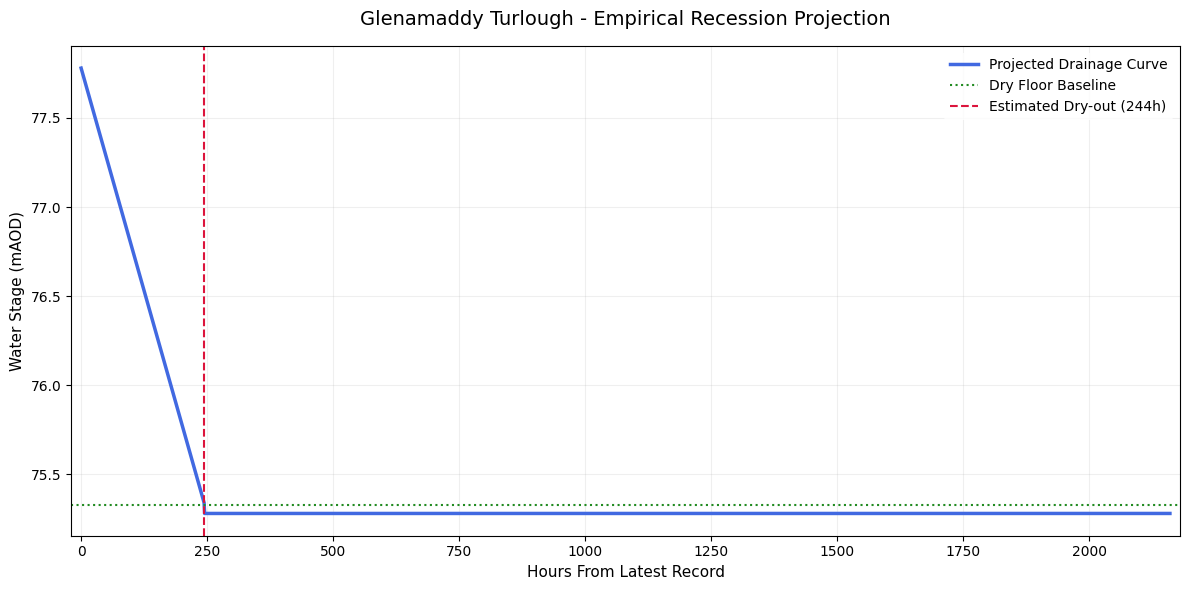

In [20]:
plt.figure(figsize=(12, 6))
plt.plot(predicted_levels, label='Projected Drainage Curve', color='royalblue', linewidth=2.5)
plt.axhline(y=dry_threshold, color='forestgreen', linestyle=':', label='Dry Floor Baseline')

if dry_hour is not None:
    plt.axvline(x=dry_hour, color='crimson', linestyle='--', label=f'Estimated Dry-out ({int(dry_hour)}h)')

plt.title('Glenamaddy Turlough - Empirical Recession Projection', fontsize=14, pad=15)
plt.xlabel('Hours From Latest Record', fontsize=11)
plt.ylabel('Water Stage (mAOD)', fontsize=11)
plt.xlim(-20, hours_to_forecast + 20)
plt.grid(True, linestyle='-', alpha=0.2)
plt.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')
plt.tight_layout()
plt.show()

In [22]:
import os
import glob
import pandas as pd

In [23]:
raw_folder = '/content/turloughs/'       # Where your messy files are
clean_folder = '/content/turloughs_clean/' # Where the clean files will go

# Create the clean directory if it doesn't exist yet
os.makedirs(clean_folder, exist_ok=True)

# Find all CSVs
csv_files = glob.glob(os.path.join(raw_folder, "*.csv"))

if len(csv_files) == 0:
    print(f"❌ No files found in {raw_folder}. Trying your default single file path...")
    # Fallback to your single file for testing if needed
    csv_files = ['/content/Glenamaddy-2021-01-01-2026-04-23.csv']

print(f"🧼 Found {len(csv_files)} file(s) to clean. Starting processing...\n")

🧼 Found 4 file(s) to clean. Starting processing...



In [24]:
for file_path in csv_files:
    file_name = os.path.basename(file_path)
    site_name = file_name.split('-')[0].split('.')[0]

    print(f"Processing: {site_name}...")
    try:
        # 1. Load Data
        df = pd.read_csv(file_path)
        initial_rows = len(df)

        # 2. Clean Timestamps
        df['Date/Time'] = pd.to_datetime(df['Date/Time'], errors='coerce')

        # Drop rows where the timestamp itself is completely missing/corrupted
        df = df.dropna(subset=['Date/Time'])

        # Set datetime index and sort chronologically (crucial for time interpolation)
        df = df.set_index('Date/Time').sort_index()

        # 3. Handle Telemetry NaNs (Stage Column)
        # Identify the exact column name for water level (handles minor spacing bugs)
        stage_col = [col for col in df.columns if 'Stage' in col]
        if not stage_col:
            print(f"⚠️ Skipping {site_name}: Could not find a 'Stage' column.")
            continue
        stage_col = stage_col[0]

        nan_count = df[stage_col].isna().sum()

        if nan_count > 0:
            # Step A: Interpolate missing values based on the time intervals between readings
            df[stage_col] = df[stage_col].interpolate(method='time')

            # Step B: If there are NaNs at the VERY BEGINNING or VERY END of the file,
            # interpolation can't reach them. We use a forward/backward fill safety net.
            df[stage_col] = df[stage_col].bfill().ffill()

            print(f"   ↳ Fixed {nan_count} missing NaN values using time-interpolation.")
        else:
            print("   ↳ 100% clean! No missing data found.")

        # 4. Save the immaculate dataset to the new clean folder
        output_path = os.path.join(clean_folder, f"{site_name}_clean.csv")

        # Reset index so 'Date/Time' becomes a normal column again in the output CSV
        df.reset_index().to_csv(output_path, index=False)
        print(f"   ↳ Saved cleaned file to: {output_path}\n")

    except Exception as e:
        print(f"❌ Failed to clean site '{site_name}': {e}\n")

print("=====================================================================")
print(f"🎉 SUCCESS! All cleaned files are stored in: {clean_folder}")
print("You can now point your comparison script to this new folder path.")
print("=====================================================================")

Processing: Fortwilliam Turlough...
   ↳ Fixed 7136 missing NaN values using time-interpolation.
   ↳ Saved cleaned file to: /content/turloughs_clean/Fortwilliam Turlough_clean.csv

Processing: Glenamaddy...
   ↳ Fixed 1650 missing NaN values using time-interpolation.
   ↳ Saved cleaned file to: /content/turloughs_clean/Glenamaddy_clean.csv

Processing: Tulla Turlough...
   ↳ Fixed 4489 missing NaN values using time-interpolation.
   ↳ Saved cleaned file to: /content/turloughs_clean/Tulla Turlough_clean.csv

Processing: Ballygalda Turlough...
   ↳ Fixed 27 missing NaN values using time-interpolation.
   ↳ Saved cleaned file to: /content/turloughs_clean/Ballygalda Turlough_clean.csv

🎉 SUCCESS! All cleaned files are stored in: /content/turloughs_clean/
You can now point your comparison script to this new folder path.


In [26]:

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =====================================================================
# 1. SETUP CLEAN PATHS & CONFIGURATION
# =====================================================================
clean_folder = '/content/turloughs_clean/'
hours_to_forecast = 24 * 90  # Extended to 90 days to see slower-draining sites

# Find all the clean files you just generated
csv_files = glob.glob(os.path.join(clean_folder, "*_clean.csv"))

if len(csv_files) == 0:
    print(f"❌ No clean CSV files found in '{clean_folder}'. Did you run the cleaning script first?")
    df_check = None
else:
    # Set up a professional multi-line plot
    plt.figure(figsize=(14, 7))
    colors = ['#4361ee', '#2a9d8f', '#7209b7', '#f72585', '#4cc9f0', '#e76f51']

    print("=====================================================================")
    print("     LAUNCHING MULTI-SITE MASTER RECESSION FORECAST                 ")
    print("=====================================================================\n")

     LAUNCHING MULTI-SITE MASTER RECESSION FORECAST                 



<Figure size 1400x700 with 0 Axes>

☀️ Fortwilliam Turlough | Current Level:  42.23 mAOD | Est. Dry-out:   0.6 Days (15 hrs)
☀️ Ballygalda Turlough | Current Level:  48.54 mAOD | Est. Dry-out:   5.2 Days (124 hrs)
☀️ Tulla Turlough  | Current Level:  10.54 mAOD | Est. Dry-out:   2.9 Days (70 hrs)
☀️ Glenamaddy      | Current Level:  77.78 mAOD | Est. Dry-out:  10.2 Days (245 hrs)


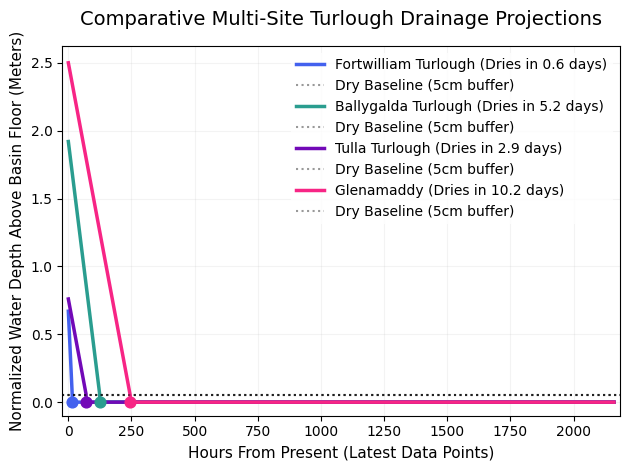

In [32]:
for idx, file_path in enumerate(csv_files):
        site_name = os.path.basename(file_path).replace('_clean.csv', '')
        color = colors[idx % len(colors)]

        df = pd.read_csv(file_path, parse_dates=['Date/Time'])
        df.set_index('Date/Time', inplace=True)

        stage_col = [col for col in df.columns if 'Stage' in col][0]

        historical_min = df[stage_col].min()
        historical_max = df[stage_col].max()
        dry_threshold = historical_min + 0.05

        df['dh'] = df[stage_col].diff()
        draining_phases = df[df['dh'] < -0.002].copy()
        draining_phases['stage_bin'] = draining_phases[stage_col].round(2)

        recession_profile = draining_phases.groupby('stage_bin')['dh'].median()
        full_range = np.arange(historical_min, historical_max + 0.01, 0.01)
        recession_profile = recession_profile.reindex(full_range).interpolate(method='linear').bfill().ffill()

        current_level = df[stage_col].iloc[-1]
        starting_level = current_level

        predicted_depths = [current_level - historical_min]
        dry_hour = None

        for hour in range(hours_to_forecast):
            # SAFE LOOKUP: Find the NEAREST matching index row rather than an exact floating-point match
            nearest_idx_loc = recession_profile.index.get_indexer([current_level], method='nearest')[0]
            hourly_drop = recession_profile.iloc[nearest_idx_loc]

            next_level = current_level + hourly_drop

            # Bound tracking constraints
            if next_level <= dry_threshold:
                next_level = historical_min
                if dry_hour is None:
                    dry_hour = hour

            # Don't let it drift outside the bounds of historical limits during loop updates
            next_level = max(min(next_level, historical_max), historical_min)

            predicted_depths.append(next_level - historical_min)
            current_level = next_level

        if dry_hour is not None:
            days = dry_hour / 24
            print(f"☀️ {site_name:15} | Current Level: {starting_level:6.2f} mAOD | Est. Dry-out: {days:5.1f} Days ({dry_hour} hrs)")
            plot_label = f"{site_name} (Dries in {days:.1f} days)"
        else:
            print(f"🌧️ {site_name:15} | Current Level: {starting_level:6.2f} mAOD | Will remain flooded for >90 days.")
            plot_label = f"{site_name} (Stays flooded)"

        plt.plot(predicted_depths, label=plot_label, color=color, linewidth=2.5)

        if dry_hour is not None:
            plt.scatter(dry_hour, 0, color=color, s=60, zorder=5)

            plt.axhline(y=0.05, color='black', linestyle=':', alpha=0.4, label='Dry Baseline (5cm buffer)')
plt.title('Comparative Multi-Site Turlough Drainage Projections', fontsize=14, pad=15)
plt.xlabel('Hours From Present (Latest Data Points)', fontsize=11)
plt.ylabel('Normalized Water Depth Above Basin Floor (Meters)', fontsize=11)

plt.grid(True, linestyle='-', alpha=0.15)
plt.xlim(-24, hours_to_forecast + 24)
plt.ylim(-0.1, None)
plt.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none', fontsize=10)
plt.tight_layout()
plt.show()